# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Raja Samudra Tandepadang
- **Email:** raja.t.padang@gmail.com
- **ID Dicoding:** rajasmdra

## Import Semua Packages/Library yang Digunakan

In [21]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [23]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [24]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.21.0


## Data Preparation

### Data Checking

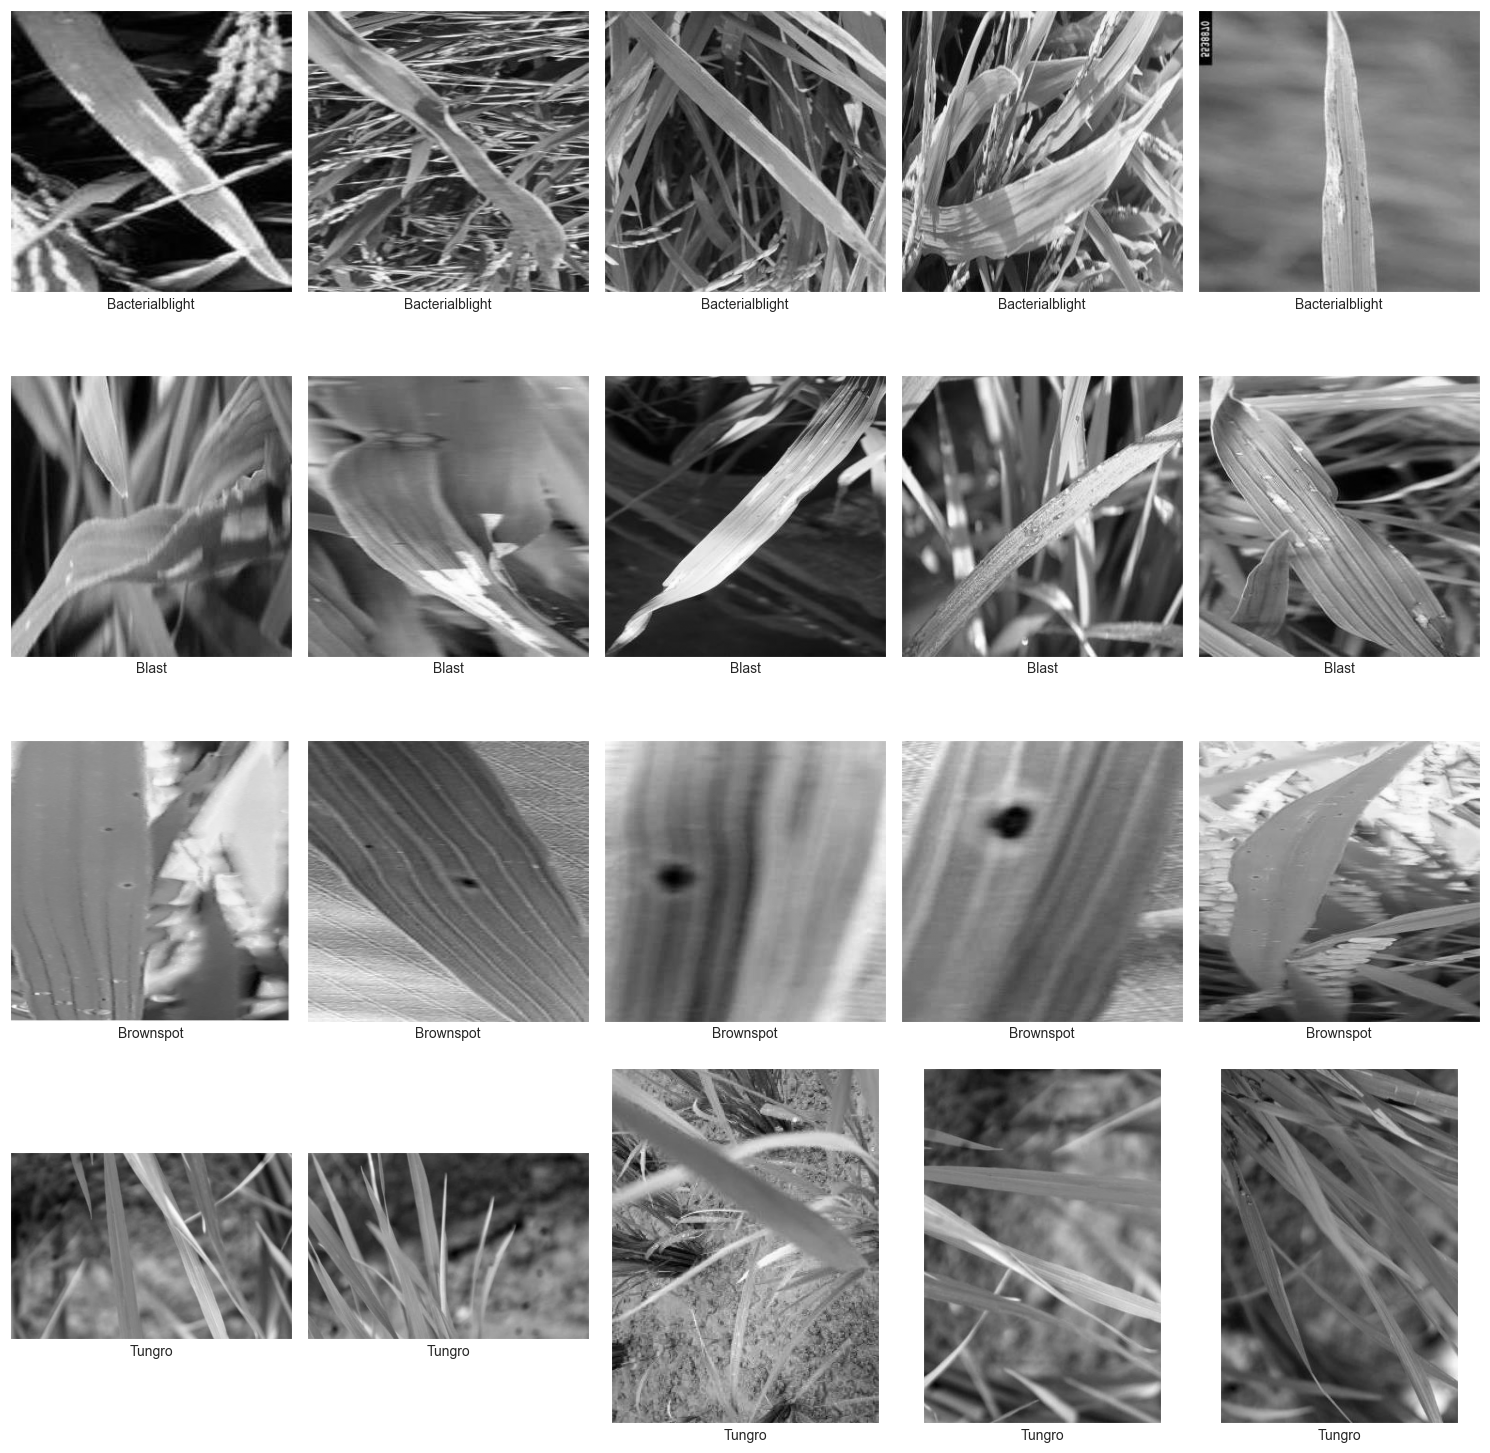

In [25]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
leaf_image = {}

# Tentukan path sumber train
path = "Rice Leaf Disease Images/"
path_sub = os.path.join(path, "")
for i in os.listdir(path_sub):
    leaf_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "Rice Leaf Disease Images/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(leaf_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(leaf_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

### PLOT DISTRIBUTION

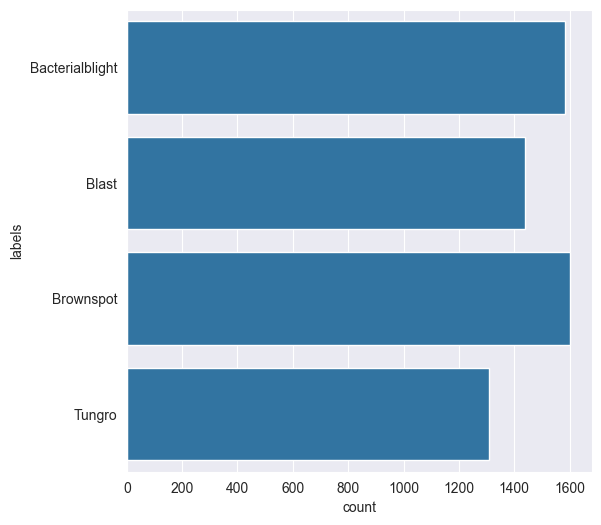

In [26]:
# Definisikan path sumber
lung_path = "Rice Leaf Disease Images/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

## Split Dataset

In [27]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'Rice Leaf Disease Images/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

labels
Bacterialblight    1584
Blast              1440
Brownspot          1600
Tungro             1308
dtype: int64

In [28]:
X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [29]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [30]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "Rice Leaf Disease Images/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels         
test   Bacterialblight     326
       Blast               296
       Brownspot           298
       Tungro              267
train  Bacterialblight    1258
       Blast              1144
       Brownspot          1302
       Tungro             1041
dtype: int64 


                                                   path           labels  \
4101      Rice Leaf Disease Images/Blast\BLAST1_032.jpg            Blast   
1791      Rice Leaf Disease Images/Blast\BLAST9_032.jpg            Blast   
854     Rice Leaf Disease Images/Tungro\TUNGRO4_273.JPG           Tungro   
4086      Rice Leaf Disease Images/Blast\BLAST5_143.JPG            Blast   
3499  Rice Leaf Disease Images/Bacterialblight\BACTE...  Bacterialblight   

        set  
4101  train  
1791  train  
854   train  
4086  train  
3499  train  


In [31]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

5932it [00:01, 3575.77it/s]


## IMAGE DATA GENERATOR

In [32]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_bacterialblight = os.path.join(TRAIN_DIR + '/Bacterialblight')
train_blast = os.path.join(TRAIN_DIR + '/Blast')
train_brownspot = os.path.join(TRAIN_DIR + '/Brownspot')
train_tungro = os.path.join(TRAIN_DIR + '/Tungro')
test_bacterialblight = os.path.join(TEST_DIR + '/Bacterialblight')
test_blast = os.path.join(TEST_DIR + '/Blast')
test_brownspot = os.path.join(TEST_DIR + '/Brownspot')
test_tungro = os.path.join(TEST_DIR + '/Tungro')

print("Total number of bacterialblight images in training set: ",len(os.listdir(train_bacterialblight)))
print("Total number of blast images in training set: ",len(os.listdir(train_blast)))
print("Total number of brownspot images in training set: ",len(os.listdir(train_brownspot)))
print("Total number of tungro images in training set: ",len(os.listdir(test_tungro)))
print("Total number of bacterialblight images in test set: ",len(os.listdir(train_bacterialblight)))
print("Total number of blast images in test set: ",len(os.listdir(test_blast)))
print("Total number of brownspot images in test set: ",len(os.listdir(test_brownspot)))
print("Total number of tungro images in test set: ",len(os.listdir(test_tungro)))

Total number of bacterialblight images in training set:  1258
Total number of blast images in training set:  1144
Total number of brownspot images in training set:  1302
Total number of tungro images in training set:  267
Total number of bacterialblight images in test set:  1258
Total number of blast images in test set:  296
Total number of brownspot images in test set:  298
Total number of tungro images in test set:  267


In [33]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Menentukan dimensi gambar & ukuran batch
# Samakan ukuran ini dengan input_shape pada layer pertama modelmu (150, 150)
IMAGE_SIZE = (150, 150) 
BATCH_SIZE = 32

# 2. Inisialisasi ImageDataGenerator (Proses Konversi ke Array + Normalisasi)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Mengonversi pixel (0-255) menjadi array float (0.0 - 1.0)
    rotation_range=20,       # Augmentasi: rotasi acak gambar
    width_shift_range=0.2,   # Augmentasi: pergeseran lebar
    height_shift_range=0.2,  # Augmentasi: pergeseran tinggi
    shear_range=0.2,         # Augmentasi: pemangkasan sudut
    zoom_range=0.2,          # Augmentasi: zoom acak
    horizontal_flip=True,    # Augmentasi: balik gambar horizontal
    fill_mode='nearest'
)

# Untuk data validasi/test, cukup lakukan konversi array & normalisasi tanpa augmentasi
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# 3. Alirkan gambar dari folder Dataset-Final ke Generator
train_generator = train_datagen.flow_from_directory(
    directory='Dataset-Final/train', 
    target_size=IMAGE_SIZE,          
    batch_size=BATCH_SIZE,
    class_mode='categorical',        # Menghasilkan output array one-hot (misal 4 kelas)
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    directory='Dataset-Final/test',  
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                    # Tetap False agar evaluasi model berurutan
)

# --- VERIFIKASI ARRAY HASIL KONVERSI ---
# Jalankan ini untuk memastikan gambar berhasil berubah menjadi array NumPy
x_batch, y_batch = next(train_generator)
print("Bentuk Array Gambar (Batch, Tinggi, Lebar, Saluran Warna):", x_batch.shape)
print("Bentuk Array Label:", y_batch.shape)

Found 4745 images belonging to 4 classes.
Found 1187 images belonging to 4 classes.
Bentuk Array Gambar (Batch, Tinggi, Lebar, Saluran Warna): (32, 150, 150, 3)
Bentuk Array Label: (32, 4)


## Modelling

In [36]:
# Reset session TensorFlow agar memori RAM tidak penuh saat melakukan training ulang
tf.keras.backend.clear_session()

# Init sequential model
model_1 = Sequential()

# ========================= Input layer & Convolutional Layers =========================
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# ========================= Fully Connected Layers =========================
# Flatten layer
model_1.add(Flatten())

# 1st Dense Layer
model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.5))

# 2nd Dense Layer
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(0.3))

# ========================= OUTPUT LAYER (DIPERBAIKI) =========================
# Dense diubah ke 4 (karena ada 4 kelas) dan aktivasi menggunakan 'softmax' untuk multi-class
model_1.add(Dense(4, activation='softmax'))

# ========================= COMPILE MODEL (DIPERBAIKI) =========================
# Loss diubah menjadi 'categorical_crossentropy'
model_1.compile(
    optimizer=tf.keras.optimizers.RMSprop(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan ringkasan struktur model yang baru
print(model_1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,403,652 (5.35 MB)

 Trainable params: 1,403,460 (5.35 MB)

 Non-trainable params: 192 (768.00 B)

None


In [38]:
count_bacterialblight, count_blast, count_brownspot, count_tungro = len(os.listdir(train_bacterialblight)), len(os.listdir(train_blast)), len(os.listdir(train_brownspot)), len(os.listdir(train_tungro))
weight_0 = (1 / count_bacterialblight) * (count_bacterialblight + count_blast + count_brownspot + count_tungro) / 2.0
weight_1 = (1 / count_blast) * (count_bacterialblight + count_blast + count_brownspot + count_tungro) / 2.0
weight_2 = (1 / count_brownspot) * (count_bacterialblight + count_blast + count_brownspot + count_tungro) / 2.0
weight_3 = (1 / count_tungro) * (count_bacterialblight + count_blast + count_brownspot + count_tungro) / 2.0

class_weights = {0 : weight_0, 1 : weight_1, 2 : weight_2, 3 : weight_3}

%time

# Fitting / training model
history_1 = model_1.fit(train_generator,
                        epochs=30,
                        batch_size=32,
                        validation_data=val_generator,
                        class_weight = class_weights)

CPU times: total: 0 ns
Wall time: 8.41 ms


KeyboardInterrupt: 

## Evaluasi dan Visualisasi

In [ ]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
 
plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [ ]:
test_generator.reset()
 
preds_1 = model_1.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
preds_1[preds_1 <= 0.5] = 0
preds_1[preds_1 > 0.5] = 1
 
# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=[0, 1, 2, 3]),index=["Actual Bacterialblight", "Actual Blast", "Actual Brownspot", "Actual Tungro"],
columns=["Actual Bacterialblight", "Actual Blast", "Actual Brownspot", "Actual Tungro"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_1,target_names =['Bacterialblight', 'Blast', 'Brownspot', 'Tungro'], digits=4))

## Konversi Model

### TFJS

## Inference (Optional)